# Lab 6: Color Models, Noise, and Filtering

This lab demonstrates color model conversion, noise addition, and filtering techniques.

## 1. Color Model Conversion

Convert the input image to different color models: Grayscale, HSV, LAB, YCrCb.

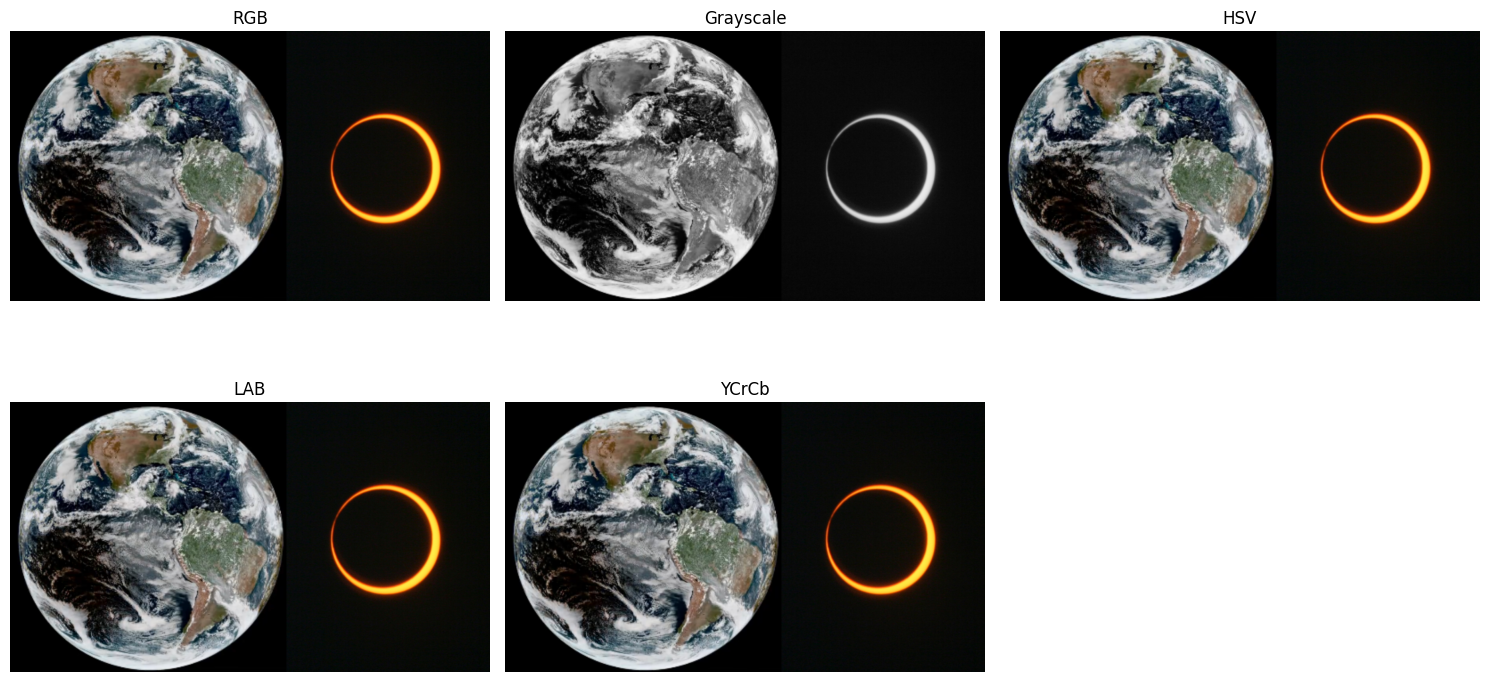

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load image (replace with your filename if needed)
img = cv2.imread('earth.png')
if img is None:\
    raise Exception('Image not found!')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to different color models
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

# Display results
plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title('RGB')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
plt.title('HSV')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB))
plt.title('LAB')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB))
plt.title('YCrCb')
plt.axis('off')
plt.tight_layout()

plt.show()

## 2. Add Noise & Apply Filters

We will add Gaussian, salt-and-pepper, and speckle noise with different densities, then apply linear (mean) and non-linear (median) filters with various mask sizes.

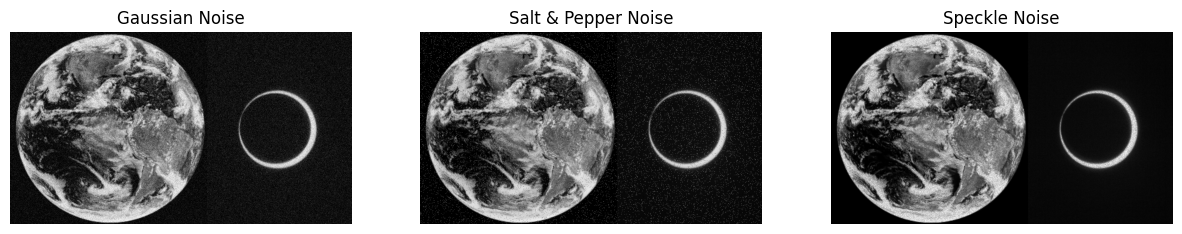

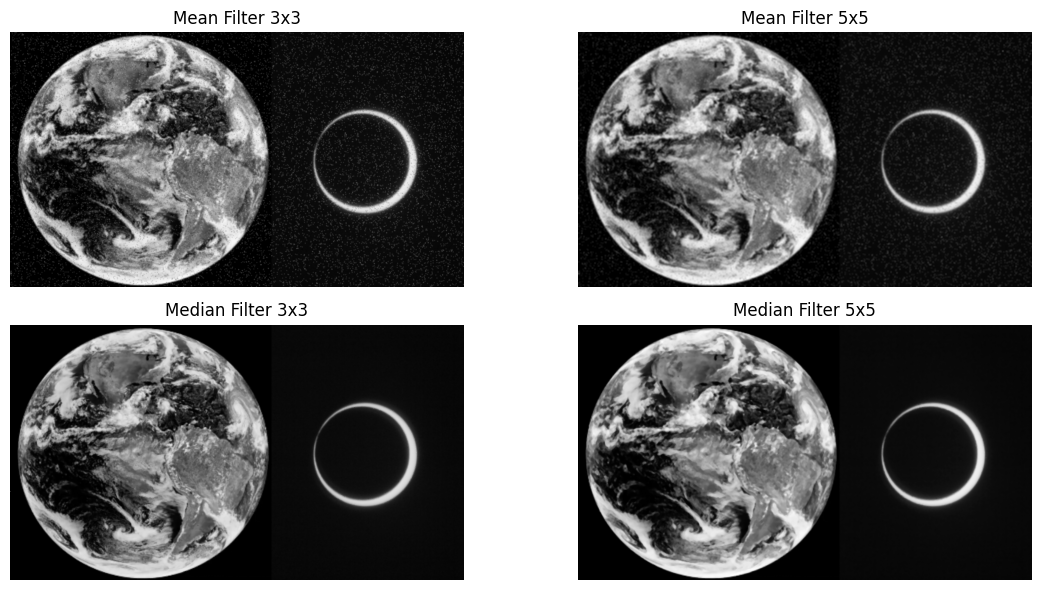

In [3]:
import numpy as np

def add_gaussian_noise(image, mean=0, std=20):
    gauss = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy = image.copy()
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    # Salt
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

def add_speckle_noise(image):
    gauss = np.random.randn(*image.shape)
    noisy = image + image * gauss * 0.2
    return np.clip(noisy, 0, 255).astype(np.uint8)

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
noises = {
    'Gaussian': add_gaussian_noise(img_gray, std=30),
    'Salt & Pepper': add_salt_pepper_noise(img_gray, 0.02, 0.02),
    'Speckle': add_speckle_noise(img_gray)
}

plt.figure(figsize=(15,5))
for i, (name, noisy_img) in enumerate(noises.items()):
    plt.subplot(1,3,i+1)
    plt.imshow(noisy_img, cmap='gray')
    plt.title(f'{name} Noise')
    plt.axis('off')
plt.show()

# Apply filters with different mask sizes
noisy_img = noises['Salt & Pepper']
mean_3 = cv2.blur(noisy_img, (3,3))
mean_5 = cv2.blur(noisy_img, (5,5))
median_3 = cv2.medianBlur(noisy_img, 3)
median_5 = cv2.medianBlur(noisy_img, 5)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.imshow(mean_3, cmap='gray')
plt.title('Mean Filter 3x3')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(mean_5, cmap='gray')
plt.title('Mean Filter 5x5')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(median_3, cmap='gray')
plt.title('Median Filter 3x3')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(median_5, cmap='gray')
plt.title('Median Filter 5x5')
plt.axis('off')
plt.tight_layout()

plt.show()

## Answers to Questions

**Q1: Key difference between linear and non-linear filters in handling edge details?**
- Linear filters (e.g., mean/average) tend to blur edges because they compute the average of pixel values, smoothing both noise and edges.
- Non-linear filters (e.g., median) preserve edges better by selecting the median value, which is less affected by outliers and does not average across edges.

**Q2: Why does median filtering work better than averaging for salt-and-pepper noise?**
- Salt-and-pepper noise consists of random black and white pixels. Median filtering removes these outliers by replacing each pixel with the median of its neighbourhood, effectively eliminating isolated noise without blurring the image.
- Averaging (mean) filter reduces noise but also blurs edges and does not remove isolated extreme values as effectively.

**Q3: Which color model is most suitable for skin detection and why?**
- The HSV and YCrCb color models are most suitable for skin detection.
- YCrCb separates luminance (Y) from chrominance (Cr, Cb), making it easier to define skin color ranges regardless of lighting.
- HSV separates color information (hue) from intensity, allowing robust skin segmentation under varying illumination.

**Summary Table:**
| Filter Type   | Edge Handling | Salt-Pepper Noise | Use Case           |
|--------------|--------------|-------------------|--------------------|
| Linear (Mean)| Blurs edges   | Poor              | General smoothing  |
| Non-linear (Median)| Preserves edges | Excellent         | Salt-pepper removal |
| HSV/YCrCb    | Good for skin | N/A               | Skin detection     |